In [ ]:
### IMPORTS

!pip install scikit_posthocs
!pip install ipython-autotime

%load_ext autotime

import string
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import scipy.stats as ss
import scikit_posthocs as scihoc
import seaborn as sns

from matplotlib import patches
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from os import listdir
from re import search
from scipy import integrate

import gspread
from google.colab import auth, drive
from google.auth import default
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)
drive.mount('/content/gdrive/', force_remount=True)

In [ ]:
### PATH

experiment_to_analyse = '' # INSERT HERE NAME OF EXPERIMENT
path = f"" # INSERT HERE PATH TO DATA

In [ ]:
### UTILITY FUNCTIONS

def stat_rounder(p):
  if p < 0.0001:
    return 'p < 0.0001'
  else:
    return f'p={str(round(p, 4))}'

def errorfill(x, y, yerr, color=None, alpha_fill=0.3, ax=None, label=None):
    ax = ax if ax is not None else plt.gca()
    if color is None:
        color = ax._get_lines.color_cycle.next()
    if np.isscalar(yerr) or len(yerr) == len(y):
        ymin = y - yerr
        ymax = y + yerr
    elif len(yerr) == 2:
        ymin, ymax = yerr
    ax.plot(x, y, color=color, label=label, linewidth = 2)
    ax.fill_between(x, ymax, ymin, color=color, alpha=alpha_fill)

### COLOR SCHEMES

colordict = {'Brassica': '#8d8089',
             'Pelt': '#50414c',
             'Brinjal': '#5e3a42',
             'Middleton Pink': '#fde7e5',
             'Calluna': '#ccc8ce',
             'Sugaroom Red': '#d0bfcd',
             'Preference Red': '#6d4247',
             'Sulking Room Pink': "#a0837f",
             'Cinder Rose': "#c6a4a6",
             'Nancys Blushes': "#ecb7b8",
             'Rangwali': "#bf7a8f",
             'Lake Red': "#c8526a",
             'Rectory Red': "#a53c49",
             'Incarnadine': "#a04344",
             'Blazer': "#b64f48",
             'Harissa': "#ae5043",
             'Charlottes Locks': "#d65f3d",
             'Book Room': "#ab6758",
             'Red Earth': "#c57b67",
             'India Yellow': "#cb9e59",
             'Sudbury Yellow': "#dcb771",
             'Babouche': "#ecc363",
             'Yellowcake': "#ebe05e",
             'Yellow Ground': "#f2cf86",
             'Dayroom Yellow': "#f7e29d",
             'Dorset Cream': "#efd5a1",
             'Tallow': "#fdedd7",
             'Farrows Cream': "#efdbb3",
             'Hay': "#dec795",
             'Citrona': "#dbcc7c",
             'Churlish Green': "#c8bd83",
             'Yeabridge Green': "#909e6e",
             'Bancha': "#686a47",
             'Duck Green': "#465741",
             'Green Ground': "#dbdab6",
             'Cooking Apple Green': "#c4c6a5",
             'Lichen': "#a1a189",
             'Breakfast Room Green': "#94a68a",
             'Calke Green': "#758769",
             'Emerald Green': "#7bae72",
             'Verdigris': "#3e8b67",
             'Vardo': "#427e83",
             'Arsenic': "#84b59c",
             'Green Smoke': "#737c70",
             'Oval Room Blue': "#8b9d9b",
             'Green Blue': "#acbdb2",
             'Dix Blue': "#99b0ab",
             'Parma Gray': "#b1bfc5",
             'Blue Ground': "#a1c5c8",
             'Stone Blue': "#7997a1",
             'Inchyra Blue': "#586768",
             'Hague Blue': "#3d4e57",
             'Stiffkey Blue': "#4d5b6a",
             'St Giles Blue': "#599ec4",
             'Ultra Marine Blue': "#5d82a1",
             'Cooks Blue': "#6a90b4",
             'Lulworth Blue': "#a0b8c8",
             'Pitch Blue': "#636e8f",
             'Imperial Purple': "#55566b",
             'Scotch Blue': "#41404c",
             'Paean Black': "#494248",
             'Railings': "#45494b",
             'Off Black': "#444546",
             'Pitch Black': "#3b3938",
             'Pigeon': "#a0a093",
             'Old White': "#cec3ad",
             'Strong White': "#e5e0db",
             'Cabbage White': "#e8eeea"}

time: 9.69 ms (started: 2025-07-07 15:39:00 +00:00)


In [ ]:
wells = []
for l in 'ABCDEFGH':
  for n in range(1, 13):
    wells.append(l + str(n))
order = pd.DataFrame(wells, columns=['Well'])
order

,Well
0,A1
1,A2
2,A3
3,A4
4,A5
...,...
91,H8
92,H9
93,H10
94,H11


time: 63.7 ms (started: 2025-07-07 15:39:02 +00:00)


In [ ]:
### DICTIONARIES FOR PLATES

sheets = {'Plate 1': 'control Inf',
          'Plate 2': 'control H2O',
          'Plate 3': '10 \u03BCM TDZ_Inf',
          'Plate 4': '10 \u03BCM TDZ_H2O',
          'Plate 5': '1 \u03BCM TDZ_Inf',
          'Plate 6': '1 \u03BCM TDZ_H2O',
          'Plate 7': 'control Inf',
          'Plate 8': 'control H2O',
          'Plate 9': '10 \u03BCM coronatine_Inf',
          'Plate 10': '10 \u03BCM coronatine_H2O',
          'Plate 11': '1 \u03BCM coronatine_Inf',
          'Plate 12': '1 \u03BCM coronatine_H2O',
          }

### DICTIONARIES FOR LABELS
first = {'1': 'pTCS2-min35S-TMV -nnLuz_v5 + MinSyn108-nnLuz_ins167_2tdT',
         '2': 'pTCS2-min35S-TMV -nnLuz_v5 + MinSyn108-nnLuz_ins167_2tdT',
         '3': 'pTCS2-min35S-TMV -nnLuz_v5 + MinSyn108-nnLuz_ins167_2tdT',
         '4': 'AtTCTP - nnLuz_v5 + MinSyn108-nnLuz_ins167_2tdT',
         '5': 'AtTCTP - nnLuz_v5 + MinSyn108-nnLuz_ins167_2tdT',
         '6': 'AtTCTP - nnLuz_v5 + MinSyn108-nnLuz_ins167_2tdT',
         '7': 'pTCS2-min35S-TMV',
         '8': 'pTCS2-min35S-TMV',
         '9': 'pTCS2-min35S-TMV',
         '10': 'MinSyn108-nnLuz_ins167_2tdT',
         '11': 'MinSyn108-nnLuz_ins167_2tdT',
         '12': 'MinSyn108-nnLuz_ins167_2tdT'}

secon = {'1': 'pORCA3 -nnLuz_v5 + MinSyn108-nnLuz_ins167_2tdT',
         '2': 'pORCA3 -nnLuz_v5 + MinSyn108-nnLuz_ins167_2tdT',
         '3': 'pORCA3 -nnLuz_v5 + MinSyn108-nnLuz_ins167_2tdT',
         '4': 'AtTCTP - nnLuz_v5 + MinSyn108-nnLuz_ins167_2tdT',
         '5': 'AtTCTP - nnLuz_v5 + MinSyn108-nnLuz_ins167_2tdT',
         '6': 'AtTCTP - nnLuz_v5 + MinSyn108-nnLuz_ins167_2tdT',
         '7': 'pORCA3-min35S-TMV',
         '8': 'pORCA3-min35S-TMV',
         '9': 'pORCA3-min35S-TMV',
         '10': 'MinSyn108-nnLuz_ins167_2tdT',
         '11': 'MinSyn108-nnLuz_ins167_2tdT',
         '12': 'MinSyn108-nnLuz_ins167_2tdT'}

### FUNCTION FOR DATA DETECTION IN TEKAN FILES

def detect_table(data: pd.DataFrame,
                 initial_start: int = 0):
    start = None
    data_r = pd.DataFrame()
    for index, val in data.iloc[initial_start:, 0].items():
        # print(f'{index}, {val}')
        if val == '<>':
            start = index + 1
            index_name = '<>'
            data_type = 'single'

            data_to_check = data.iloc[start:start + 8, 1:13].replace(r'nan|None', np.nan, regex=True)
            data_to_check = data_to_check.select_dtypes(include=[np.number])
            index_col = data.iloc[start:start + 8, 0]

            if data_to_check.notna().values.any():
              data_r = pd.concat([index_col, data_to_check], axis=1)
              break
        elif val == 'Cycle Nr.':
            start = index + 1
            for index_, val_ in  enumerate(data.iloc[start:, 0]):
                if val_ == 'End Time':
                    end = index_ - 1
                    data_to_check = data.iloc[start:end, 1:]
                    data_to_check.drop('Temp. [°C]', inplace=True, axis=1)
                    data_to_check.dropna(axis=1, how='all', inplace=True)
                    index_col = data.iloc[start:end, 0]
                    print(index_col)
                    index_name = '<>'
                    data_type = 'kinetics'
                    if data_to_check.notna().values.any():
                      data_r = pd.concat([index_col, data_to_check], axis=1)
                      break


    if not data_r.empty:
      data_r.columns = data.iloc[index].values.tolist()
      data_r.set_index(index_name, inplace=True)
      data_r.columns.name = None
      well_names = []
      for row_name in data_r.index.values.tolist():
        for col_name in data_r.columns.values.tolist():
          well_names.append(row_name+str(col_name))
      data_flat = pd.DataFrame({'values': data_r.values.ravel(), 'Well': well_names})

      return data_flat, start, data_type, data_r
    else:
        return 'error', 'error', 'error', 'error'

### DATA OPENING AND PROCESSING

filelist = [x for x in listdir(path) if x.endswith('.xlsx')]

def sort_func(elem):
  return float(elem.split('.')[0].replace('h', '').replace(',', '.'))
filelist.sort(key = sort_func)
print(filelist)
full_data = pd.DataFrame()
time = []
for file_num, filename in enumerate(filelist[:]):
  file = pd.ExcelFile(f'{path}{filename}')
  file_df_533 = pd.DataFrame()
  file_df_593 = pd.DataFrame()
  file_df_ratio = pd.DataFrame()

  print(f'file: {filename}')
  time_point_name = filename.split('.')[0].replace(',', '.')
  time.append(time_point_name)
  for sheet_num, sheet_name in enumerate(file.sheet_names[:]):
      print(sheet_name)
      if sheet_num < 6:
        labels = first
      else:
        labels = secon

      sheet = pd.read_excel(file, sheet_name = sheet_name)
      file_df_533_sheet = order.copy()
      file_df_593_sheet = order.copy()
      file_df_ratio_sheet = order.copy()

      raw_data_533, next_start_533, data_type, data_r_533 = detect_table(data=sheet)
      raw_data_593, next_start_593, data_type, data_r_593 = detect_table(data=sheet,
                                                            initial_start = next_start_533)

      file_df_533_sheet = file_df_533_sheet.merge(right = raw_data_533,
                                                  how = 'inner',
                                                  on = ['Well'])
      file_df_533_sheet.rename(columns = {'values': time_point_name}, inplace = True)
      file_df_533_sheet['Sheet_name'] = sheet_name

      file_df_593_sheet = file_df_593_sheet.merge(right = raw_data_593,
                                                  how = 'inner',
                                                  on = ['Well'])
      file_df_593_sheet.rename(columns = {'values': time_point_name}, inplace = True)
      file_df_593_sheet['Sheet_name'] = sheet_name

      well_names = []
      for row_name in data_r_533.index.values.tolist():
        for col_name in data_r_533.columns.values.tolist():
          well_names.append(row_name+col_name)
      raw_data_ratio = pd.DataFrame({'values': data_r_533.values.ravel()/data_r_593.values.ravel(), 'Well': well_names})
      file_df_ratio_sheet = file_df_ratio_sheet.merge(right = raw_data_ratio,
                                                      how = 'inner',
                                                      on = 'Well')
      file_df_ratio_sheet.rename(columns = {'values': time_point_name}, inplace = True)
      file_df_ratio_sheet['Sheet_name'] = sheet_name

      file_df_533_sheet['Label'] = file_df_533_sheet.apply(lambda row: labels[row['Well'][1:]], axis = 1)
      file_df_593_sheet['Label'] = file_df_593_sheet.apply(lambda row: labels[row['Well'][1:]], axis = 1)
      file_df_ratio_sheet['Label'] = file_df_ratio_sheet.apply(lambda row: labels[row['Well'][1:]], axis = 1)

      file_df_533 = pd.concat([file_df_533, file_df_533_sheet], axis = 0)
      file_df_593 = pd.concat([file_df_593, file_df_593_sheet], axis = 0)
      file_df_ratio = pd.concat([file_df_ratio, file_df_ratio_sheet], axis = 0)

      file_df_533['Wavelength'] = '533 nm'
      file_df_593['Wavelength'] = '593 nm'
      file_df_ratio['Wavelength'] = '533/593 nm'

  file_df = pd.concat([file_df_533, file_df_593, file_df_ratio], axis = 0)

  if file_num == 0:
    full_data = file_df
  else:
    full_data = full_data.merge(right = file_df,
                                how = 'inner',
                                on = ['Well', 'Wavelength', 'Sheet_name'])
full_data['Sum'] = full_data[time].sum(axis = 1)
full_data['Sheet_label'] = full_data.apply(lambda row: sheets[row['Sheet_name']], axis = 1)
full_data = full_data[['Well', 'Label', 'Sheet_name', 'Sheet_label', 'Wavelength', 'Sum'] + time]

# removal of bad wells
ignoring = [['Plate 3', 'H2'], ['Plate 4', 'A4'], ['Plate 7', 'H6'], ['Plate 7', 'H12']]
for ignore in ignoring:
  full_data.drop(full_data[(full_data['Sheet_name'] == ignore[0]) & (full_data['Well'] == ignore[1])].index, inplace = True)


full_data.to_csv(f'{path}full_data_clean.csv', index = False)
full_data

In [ ]:
### DICTIONARIES FOR LABELS CORRECTIONS

rename_dict = {
    'pTCS2-Luz533 + MinSyn108-Luz590': 'Ratiometric sensor',
    'AtTCTP-Luz533 + MinSyn108-Luz590': 'Constitutive red luciferase + Constitutive green luciferase',
    'pTCS2-Luz533': 'Non-ratiometric sensor',
    'MinSyn108-Luz590': 'Constitutive red luciferase',
}
full_data['Label'] = full_data['Label'].replace(rename_dict)

rename_dict = {
    'control Inf': 'control',
    '10 μM TDZ_Inf': '10 μM TDZ',
    '1 μM TDZ_Inf': '1 μM TDZ',
}
full_data['Sheet_label'] = full_data['Sheet_label'].replace(rename_dict)
full_data

time: 7.6 ms (started: 2025-07-07 16:06:02 +00:00)


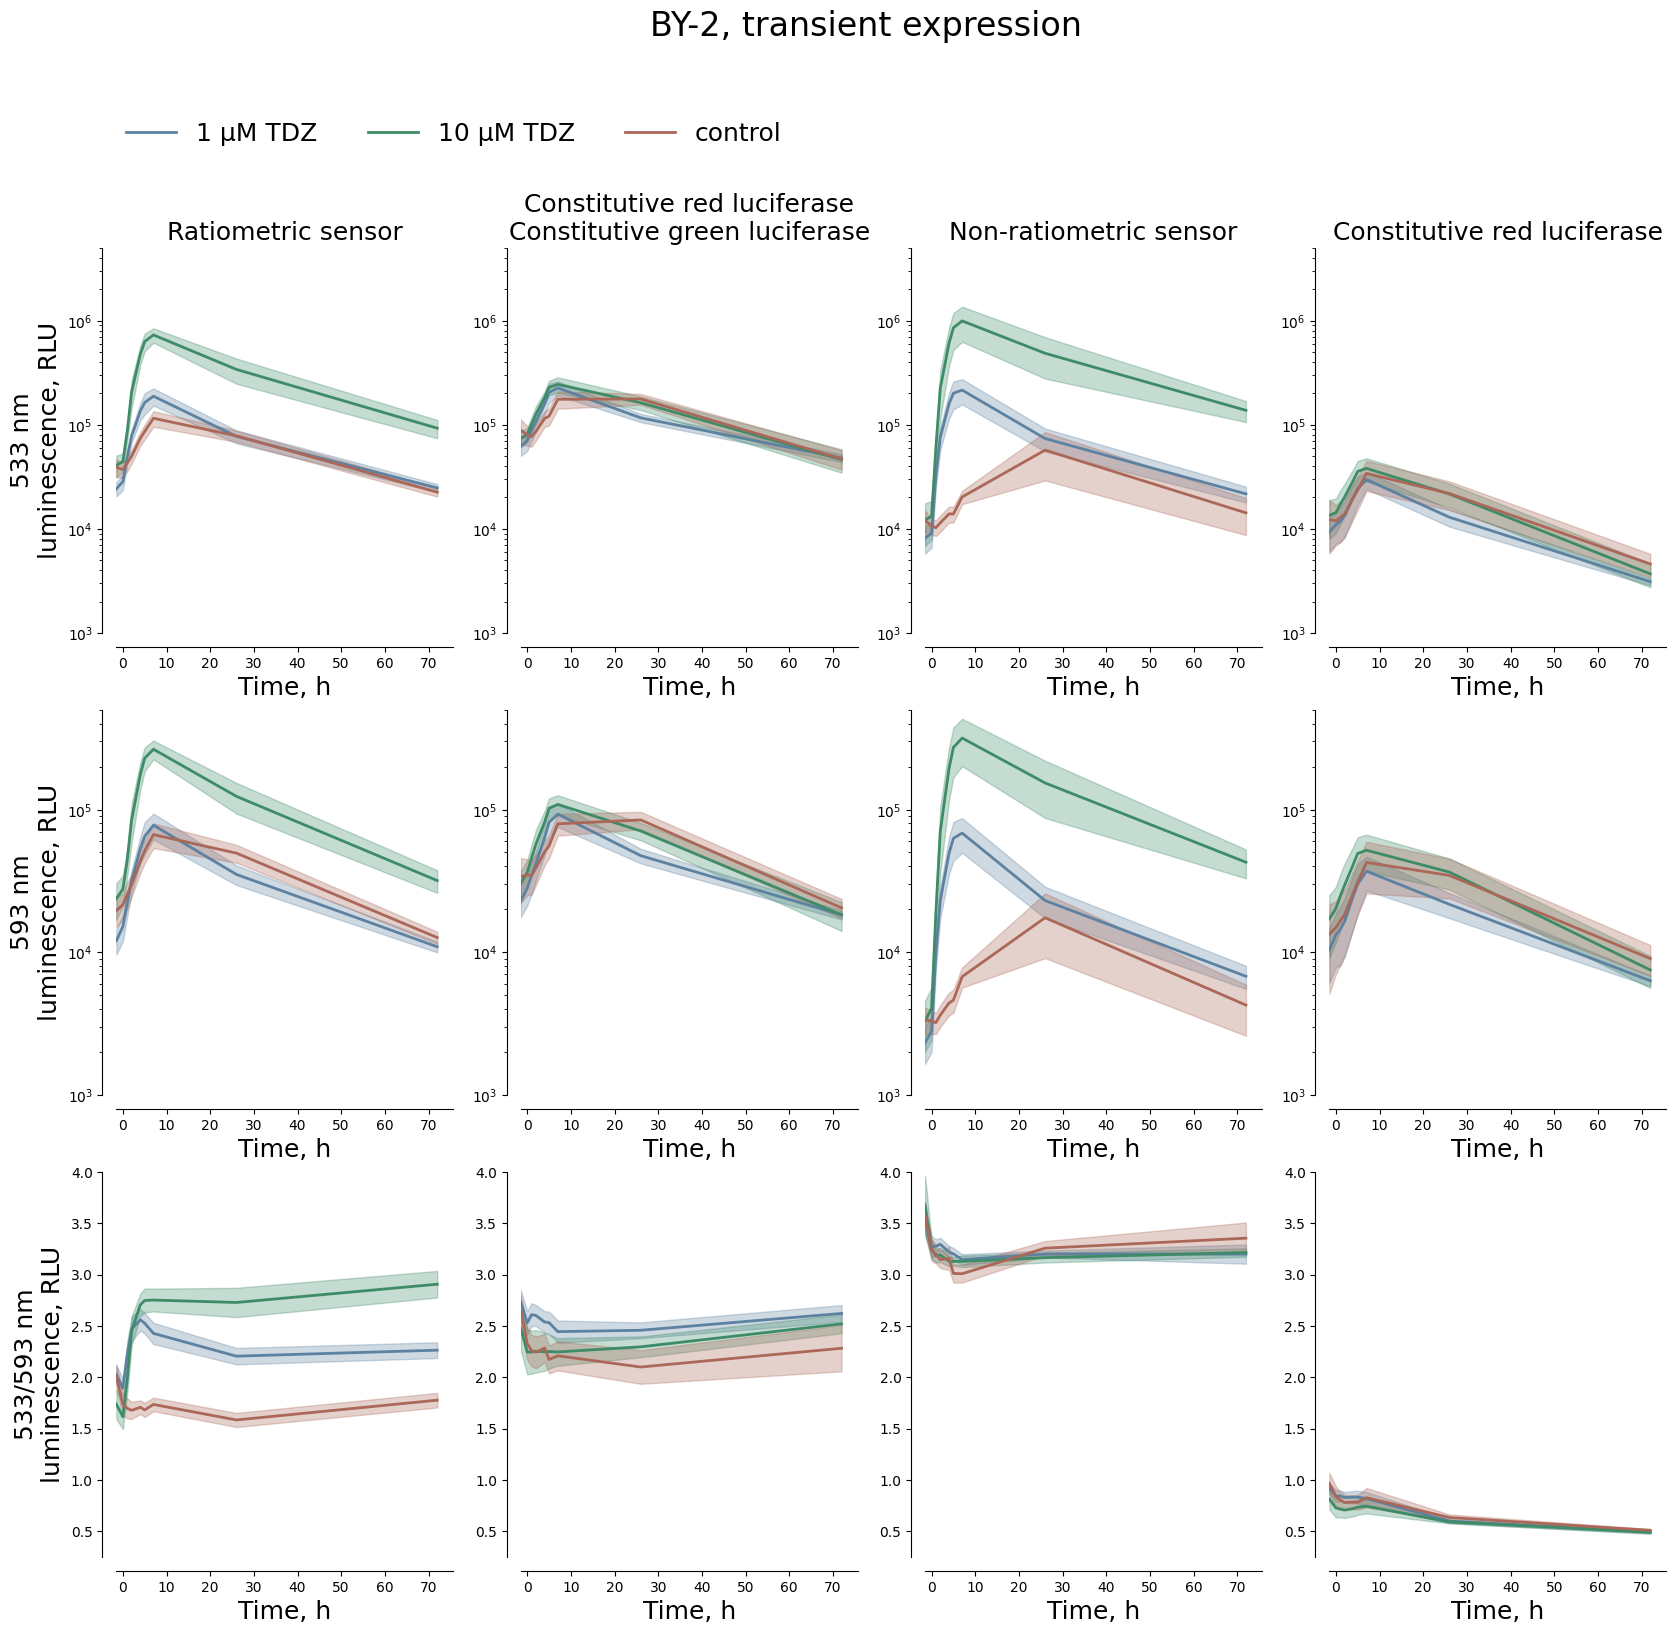

time: 10.9 s (started: 2025-07-07 16:06:13 +00:00)


In [ ]:
filter = 'Wavelength'

filter_value_1 = '533/593 nm'

filter_value_2 = [f'Plate {str(x)}' for x in range(1, 7)]

filter_value_3 = 'H2O'


data_start_col = 6
time = [float(x.replace('h', '')) for x in full_data.columns.tolist()[data_start_col:]]

colors_ratio = {'control': 'Book Room',
                'control H2O': 'Lulworth Blue',
                '10 μM TDZ': 'Verdigris',
                '10 \u03BCM TDZ_H2O': 'Hague Blue',
                '1 μM TDZ': 'Ultra Marine Blue',
                '1 \u03BCM TDZ_H2O': 'St Giles Blue'}

colors_533 = {'temp': 'Blue Ground',
              'inf': 'Charlottes Locks',
              'control (-)': 'Yellowcake'}

xlabel_size = 18
ylabel_size = 18
yticklabel_size = 15
xticklabel_size = 15
title_size = 24
suptitle_size = 18
legend_size = 18
signplot_size = 13
instick_size = 9

full_data = full_data[
    (full_data.Sheet_name.isin(filter_value_2)) &
    (~full_data.Sheet_label.str.contains(filter_value_3, na=False))
]
plots = full_data.Label.unique().tolist()
waves = full_data.Wavelength.unique().tolist()
fig, axes = plt.subplots(len(waves), len(plots), figsize = (20, 17), gridspec_kw={'hspace': 0.2, 'wspace': 0.2})
for plot_index, plot in enumerate(plots):
  for wave_index, wave in enumerate(waves):

    ax = axes[wave_index, plot_index]

    data_slice = full_data[(full_data.Label == plot) & (full_data[filter] == wave)]
    data_slice_grouped = data_slice[['Sheet_label'] + data_slice.columns[-len(time):].values.tolist()].groupby('Sheet_label').describe()


    for index_num, index in enumerate(data_slice_grouped.index.values.tolist()):
      mean = data_slice_grouped.xs('mean', axis = 1, level = 1).loc[index]
      std = data_slice_grouped.xs('std', axis = 1, level = 1).loc[index]
      errorfill(time, mean, std, color = colordict[colors_ratio[index]], ax = ax, label = index)

    sns.despine(offset = 10, trim = False, ax=ax)
    if plot_index == 0:
      ax.set_ylabel(f'{wave}\nluminescence, RLU', fontsize = ylabel_size)
    else:
      ax.set_ylabel(None)
    ax.set_xlabel('Time, h', fontsize = xlabel_size)

    if wave_index == 0 and plot_index == 0:
      ax.legend(loc = (0.0, 1.24), frameon = False, fontsize = legend_size, ncol = len(filter_value_2)/2)


    if wave_index == 0:
      ax.set_ylim(1000, 5000000)
      ax.set_yscale('log')
    elif wave_index == 1:
      ax.set_ylim(1000, 500000)
      ax.set_yscale('log')
    elif wave_index == 2:
      ax.set_ylim(0.25, 4)
      ax.set_yscale('linear')
    ax.set_xlim(-1.5)
    title = plot.replace(' + ', '\n')
    if wave_index == 0:
      ax.set_title(f'{title}', fontsize = suptitle_size, y = 1.00)

plt.suptitle(f"BY-2, transient expression", fontsize = title_size, y = 1.02)


ver = 'ver2.0'

plot_name = '' # INSERT HERE NAME FOR PLOT
plt.savefig(f'{path}{experiment_to_analyse}_{plot_name}_{filter_value_3}_not_normed_{ver}.png',
            dpi = 400,
            bbox_inches='tight',
            transparent=False,
            facecolor='white')
plt.savefig(f'{path}{experiment_to_analyse}_{plot_name}_{filter_value_3}_not_normed_{ver}.pdf',
            bbox_inches='tight',
            transparent=False,
            facecolor='white')